In [1]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')   # Ubuntu: sudo apt install fonts-nanum
plt.rc('axes', unicode_minus=False)

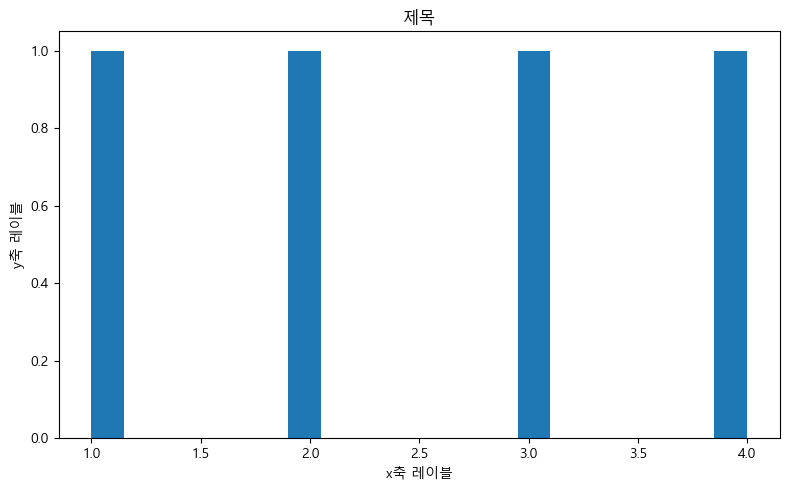

<Figure size 640x480 with 0 Axes>

In [5]:
# ✅ 객체형 (권장)
fig, ax = plt.subplots(figsize=(8, 5))   # fig=도화지, ax=그림 영역
data = {1,2,3,4}
ax.hist(data, bins=20)
ax.set_title('제목')
ax.set_xlabel('x축 레이블')
ax.set_ylabel('y축 레이블')
plt.tight_layout()
plt.show()

# PNG로 저장
plt.savefig('chart.png', dpi=150, bbox_inches='tight')

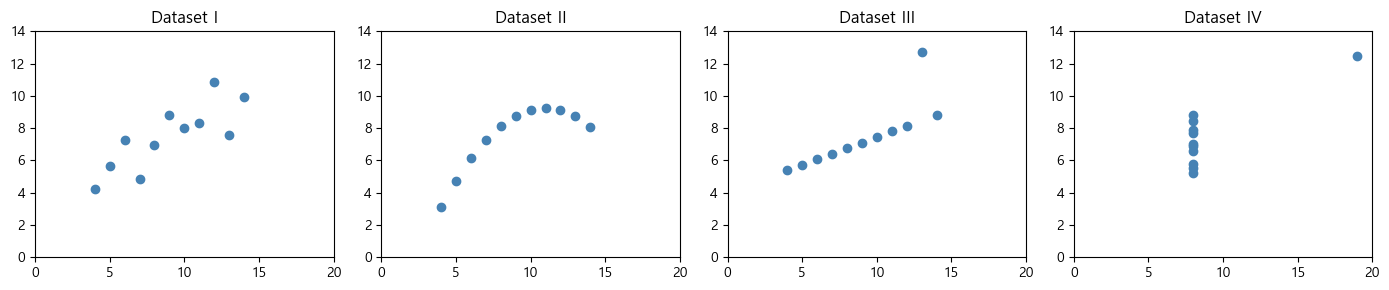

In [4]:
import matplotlib.pyplot as plt

datasets = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
             'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))   # fig = 도화지, axes = 4개 그림 영역

for ax, (name, d) in zip(axes, datasets.items()):
    ax.scatter(d['x'], d['y'], color='steelblue')
    ax.set_title(f'Dataset {name}')
    ax.set_xlim(0, 20); ax.set_ylim(0, 14)

plt.tight_layout()
plt.show()

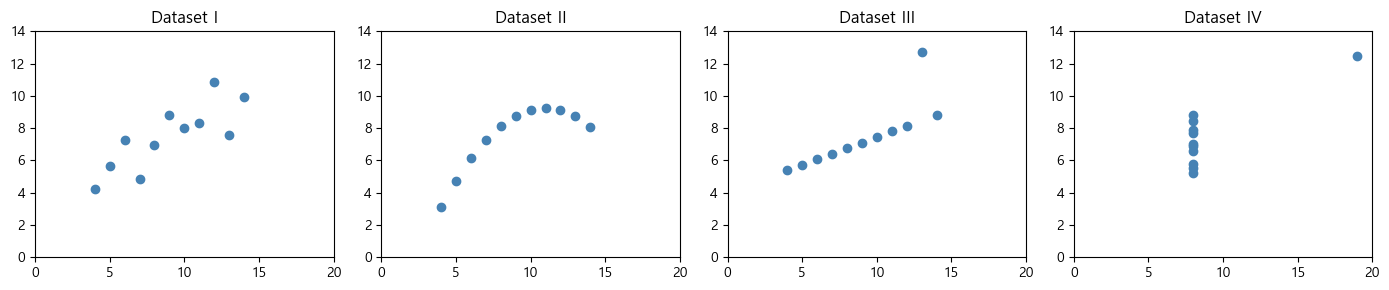

In [6]:
import matplotlib.pyplot as plt

datasets = {
    'I':   {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},
    'II':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},
    'III': {'x': [10,8,13,9,11,14,6,4,12,7,5],
             'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},
    'IV':  {'x': [8,8,8,8,8,8,8,19,8,8,8],
             'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))   # fig = 도화지, axes = 4개 그림 영역

for ax, (name, d) in zip(axes, datasets.items()):
    ax.scatter(d['x'], d['y'], color='steelblue')
    ax.set_title(f'Dataset {name}')
    ax.set_xlim(0, 20); ax.set_ylim(0, 14)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(TITANIC_URL)
titanic_clean = titanic.copy()
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())

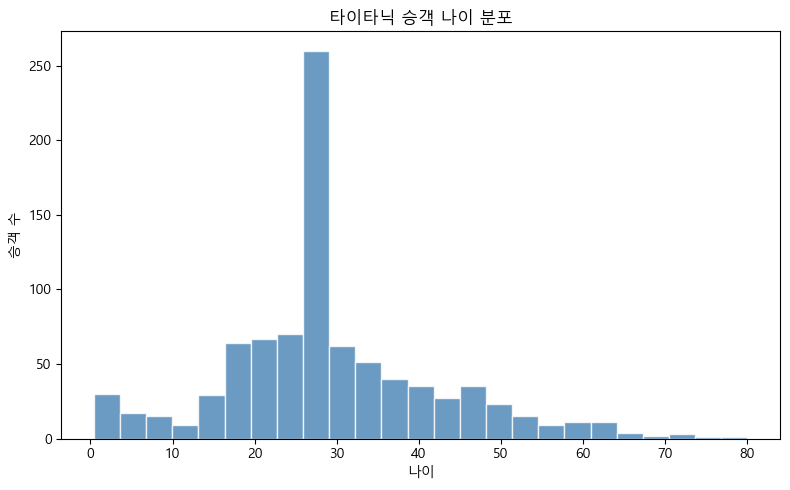

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(titanic_clean['Age'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('나이'); ax.set_ylabel('승객 수')
ax.set_title('타이타닉 승객 나이 분포')
plt.tight_layout(); plt.show()

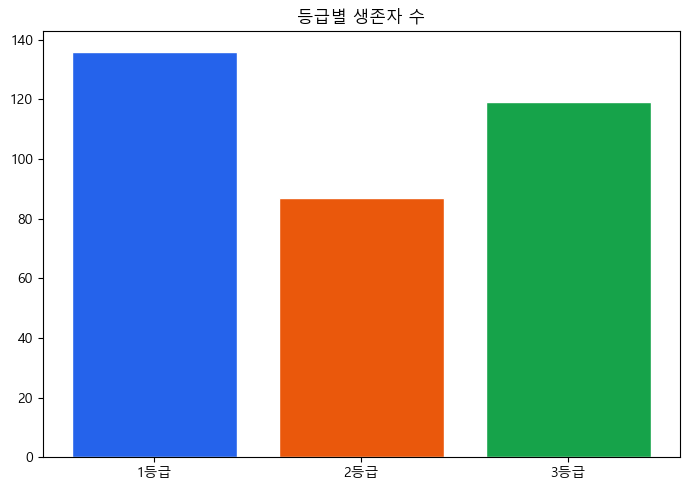

In [13]:
surv_class = titanic.groupby('Pclass')['Survived'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(surv_class.index, surv_class.values,
       color=['#2563eb','#ea580c','#16a34a'], edgecolor='white')
ax.set_title('등급별 생존자 수')
ax.set_xticks([1,2,3]); ax.set_xticklabels(['1등급','2등급','3등급'])
plt.tight_layout(); plt.show()

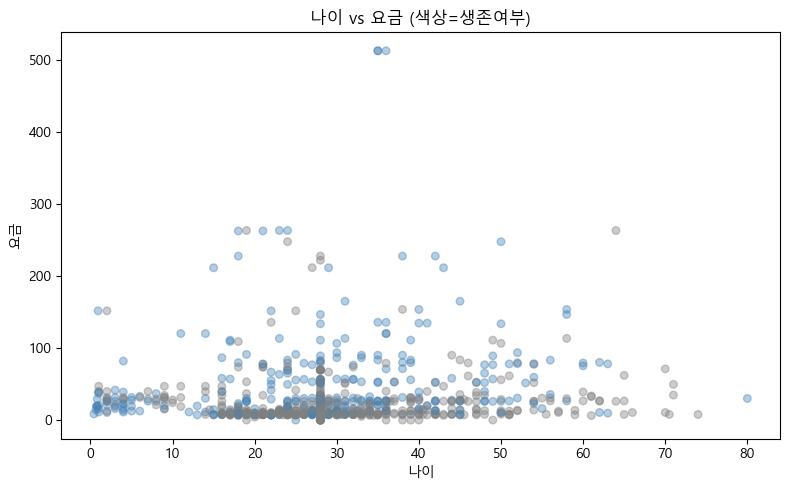

In [14]:
colors = titanic_clean['Survived'].map({0: 'gray', 1: 'steelblue'})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(titanic_clean['Age'], titanic_clean['Fare'],
           c=colors, alpha=0.4, s=30)
ax.set_xlabel('나이'); ax.set_ylabel('요금')
ax.set_title('나이 vs 요금 (색상=생존여부)')
plt.tight_layout(); plt.show()

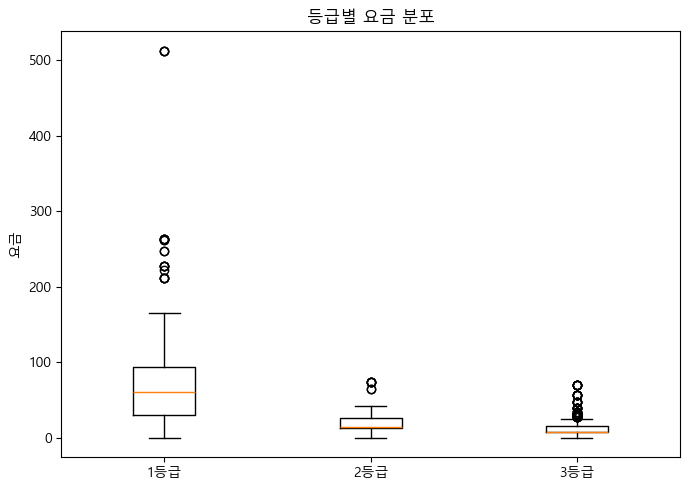

In [15]:
data_by_class = [titanic[titanic['Pclass']==c]['Fare'].dropna() for c in [1,2,3]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data_by_class, tick_labels=['1등급','2등급','3등급'])
ax.set_ylabel('요금'); ax.set_title('등급별 요금 분포')
plt.tight_layout(); plt.show()

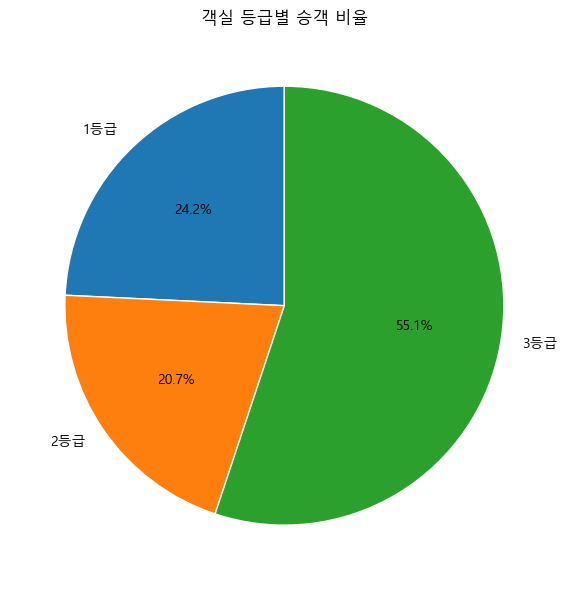

In [16]:
class_counts = titanic['Pclass'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(class_counts.values, labels=['1등급','2등급','3등급'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('객실 등급별 승객 비율')
plt.tight_layout(); plt.show()